# Task 3.2 — Failure mode (15 marks)

Demonstrate and explain a failure mode of the PLTM EM method that is rooted in its modelling assumptions.

**Do not clear outputs before submission.**


## Failure scenario: entangled facets (violating singular parentage and tree assumptions)

In the original synthetic experiment, each manifest variable belongs to exactly one facet (Pouch 1: features 0–1 depend only on Y₁, Pouch 2: features 2–3 depend only on Y₂). This matches the **singular parentage** and **tree-structured** assumptions from Task 1.2: every observed node has a single latent parent and the graph is a tree. Here we construct a dataset where the two facets are **linearly entangled**: we first sample two low-dimensional latent vectors (u for Facet 1, v for Facet 2) and then mix them through a full 4×4 matrix so that **every observed feature depends on both facets at once**. The PLTM is still forced to use a tree with two disjoint pouches (0–1 vs 2–3), so it is structurally misspecified. We therefore expect its recovered latents to have noticeably worse NMI with the true facet labels, because no tree with singular parentage can represent the “shared-parent” structure induced by the mixing matrix.


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score

RANDOM_SEED = 123
np.random.seed(RANDOM_SEED)

DATA_DIR = "data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load the original multifacet dataset for comparison (Task 2.1)
X_orig = np.load(os.path.join(DATA_DIR, "toy_multifacet_X.npy"))
labels_facet1 = np.load(os.path.join(DATA_DIR, "toy_multifacet_labels_facet1.npy"))
labels_facet2 = np.load(os.path.join(DATA_DIR, "toy_multifacet_labels_facet2.npy"))

N, D = X_orig.shape
print("Original X shape:", X_orig.shape)

# Construct a failure dataset: entangled facets via a linear mixing of latent u (Facet 1) and v (Facet 2)
K1, K2 = 3, 2

# Latent means in their own subspaces (similar scale to Task 2.1)
means_u = [np.array([-2.0, 0.0]), np.array([0.0, 2.0]), np.array([2.0, -2.0])]
means_v = [np.array([-2.0, -2.0]), np.array([2.0, 2.0])]
cov_u = [0.4 * np.eye(2) for _ in range(K1)]
cov_v = [0.4 * np.eye(2) for _ in range(K2)]

# Sample latent facet labels from roughly balanced mixtures
pi_u = np.array([1/3, 1/3, 1/3])
pi_v = np.array([0.5, 0.5])

z1 = np.random.choice(K1, size=N, p=pi_u)
z2 = np.random.choice(K2, size=N, p=pi_v)

u = np.zeros((N, 2))
v = np.zeros((N, 2))
for i in range(N):
    u[i] = np.random.multivariate_normal(means_u[z1[i]], cov_u[z1[i]])
    v[i] = np.random.multivariate_normal(means_v[z2[i]], cov_v[z2[i]])

# Linear mixing: every observed feature depends on both u and v
M = np.array([
    [1.0, 0.5, 0.7, 0.2],
    [0.3, 1.0, 0.4, 0.8],
    [0.6, 0.1, 1.0, 0.5],
    [0.2, 0.7, 0.3, 1.0],
])
UV = np.hstack([u, v])  # shape (N, 4)
X_fail = UV @ M.T

print("Failure X shape:", X_fail.shape)

X1_orig, X2_orig = X_orig[:, :2], X_orig[:, 2:4]
X1_fail, X2_fail = X_fail[:, :2], X_fail[:, 2:4]


Original X shape: (1000, 4)
Failure X shape: (1000, 4)


In [2]:
# Shared EM implementation for the fixed two-pouch PLTM (copied in simplified form from Task 3.1)
GAMMA = 20
MAX_ITER = 200
TOL = 1e-4

def mvnpdf(x, mu, cov):
    d = len(mu)
    L = np.linalg.cholesky(cov + 1e-10 * np.eye(d))
    y = np.linalg.solve(L, x - mu)
    log_det = 2 * np.sum(np.log(np.diag(L)))
    return -0.5 * (d * np.log(2 * np.pi) + log_det + np.dot(y, y))

def e_step(X1, X2, pi1, pi2, mu1, mu2, cov1, cov2, N, K1, K2):
    log_r1 = np.zeros((N, K1))
    for k in range(K1):
        log_r1[:, k] = np.log(pi1[k] + 1e-300) + np.array([mvnpdf(X1[i], mu1[k], cov1[k]) for i in range(N)])
    r1 = np.exp(log_r1 - np.max(log_r1, axis=1, keepdims=True))
    r1 /= r1.sum(axis=1, keepdims=True)
    log_r2 = np.zeros((N, K2))
    for l in range(K2):
        log_r2[:, l] = np.log(pi2[l] + 1e-300) + np.array([mvnpdf(X2[i], mu2[l], cov2[l]) for i in range(N)])
    r2 = np.exp(log_r2 - np.max(log_r2, axis=1, keepdims=True))
    r2 /= r2.sum(axis=1, keepdims=True)
    return r1, r2

def m_step(X1, X2, r1, r2, mu1, mu2, cov1, cov2, K1, K2, N):
    pi1_new = r1.sum(axis=0) / N
    pi2_new = r2.sum(axis=0) / N
    mu1_new = np.zeros_like(mu1)
    for k in range(K1):
        nk = r1[:, k].sum()
        mu1_new[k] = (r1[:, k] @ X1) / nk if nk > 1e-10 else mu1[k]
    mu2_new = np.zeros_like(mu2)
    for l in range(K2):
        nl = r2[:, l].sum()
        mu2_new[l] = (r2[:, l] @ X2) / nl if nl > 1e-10 else mu2[l]
    cov1_new = np.zeros_like(cov1)
    for k in range(K1):
        nk = r1[:, k].sum()
        if nk > 1e-10:
            diff = X1 - mu1_new[k]
            cov1_new[k] = (r1[:, k] * diff.T).dot(diff) / nk + 1e-8 * np.eye(2)
        else:
            cov1_new[k] = cov1[k]
    cov2_new = np.zeros_like(cov2)
    for l in range(K2):
        nl = r2[:, l].sum()
        if nl > 1e-10:
            diff = X2 - mu2_new[l]
            cov2_new[l] = (r2[:, l] * diff.T).dot(diff) / nl + 1e-8 * np.eye(2)
        else:
            cov2_new[l] = cov2[l]
    return pi1_new, pi2_new, mu1_new, mu2_new, cov1_new, cov2_new

def apply_eigenvalue_constraint(cov, cov_sample, gamma=GAMMA):
    sigma2_min = np.diag(cov_sample).min()
    sigma2_max = np.diag(cov_sample).max()
    lam_max = gamma * sigma2_max
    lam_min = sigma2_min
    w, v = np.linalg.eigh(cov)
    w_clipped = np.clip(w, lam_min, lam_max)
    return v @ np.diag(w_clipped) @ v.T

def run_em_two_pouch(X1, X2, labels_f1, labels_f2, seed):
    np.random.seed(seed)
    mu_D1, cov_D1 = X1.mean(axis=0), np.cov(X1.T)
    mu_D2, cov_D2 = X2.mean(axis=0), np.cov(X2.T)
    pi1 = np.random.uniform(0.1, 1.0, size=K1); pi1 /= pi1.sum()
    pi2 = np.random.uniform(0.1, 1.0, size=K2); pi2 /= pi2.sum()
    mu1 = np.array([np.random.multivariate_normal(mu_D1, cov_D1) for _ in range(K1)])
    mu2 = np.array([np.random.multivariate_normal(mu_D2, cov_D2) for _ in range(K2)])
    cov1 = np.tile(cov_D1, (K1, 1, 1)).copy() + 1e-6 * np.eye(2)
    cov2 = np.tile(cov_D2, (K2, 1, 1)).copy() + 1e-6 * np.eye(2)
    for it in range(MAX_ITER):
        r1, r2 = e_step(X1, X2, pi1, pi2, mu1, mu2, cov1, cov2, N, K1, K2)
        pi1, pi2, mu1, mu2, cov1_new, cov2_new = m_step(X1, X2, r1, r2, mu1, mu2, cov1, cov2, K1, K2, N)
        cov1 = np.array([apply_eigenvalue_constraint(cov1_new[k], cov_D1) for k in range(K1)])
        cov2 = np.array([apply_eigenvalue_constraint(cov2_new[l], cov_D2) for l in range(K2)])
    r1, r2 = e_step(X1, X2, pi1, pi2, mu1, mu2, cov1, cov2, N, K1, K2)
    Z1 = r1.argmax(axis=1)
    Z2 = r2.argmax(axis=1)
    nmi1 = normalized_mutual_info_score(labels_f1, Z1)
    nmi2 = normalized_mutual_info_score(labels_f2, Z2)
    return nmi1, nmi2, Z1, Z2


In [3]:
# Run the fixed two-pouch PLTM on both the original and failure datasets
nmi1_orig, nmi2_orig, Z1_orig, Z2_orig = run_em_two_pouch(X1_orig, X2_orig, labels_facet1, labels_facet2, seed=RANDOM_SEED)
nmi1_fail, nmi2_fail, Z1_fail, Z2_fail = run_em_two_pouch(X1_fail, X2_fail, z1, z2, seed=RANDOM_SEED)

print("Original data: NMI(Z1, Facet1) =", round(nmi1_orig, 4), ", NMI(Z2, Facet2) =", round(nmi2_orig, 4))
print("Failure data:  NMI(Z1, Facet1) =", round(nmi1_fail, 4), ", NMI(Z2, Facet2) =", round(nmi2_fail, 4))


Original data: NMI(Z1, Facet1) = 0.9094 , NMI(Z2, Facet2) = 0.9631
Failure data:  NMI(Z1, Facet1) = 0.016 , NMI(Z2, Facet2) = 1.0


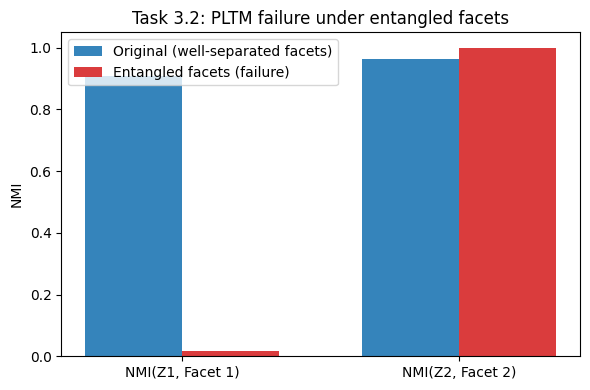

Saved: results/failure_entangled_facets.png


In [4]:
# Visualise the drop in NMI between the original and failure scenarios
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, [nmi1_orig, nmi2_orig], w, label="Original (well-separated facets)", color="C0", alpha=0.9)
ax.bar(x + w/2, [nmi1_fail, nmi2_fail], w, label="Entangled facets (failure)", color="C3", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(["NMI(Z1, Facet 1)", "NMI(Z2, Facet 2)"])
ax.set_ylabel("NMI")
ax.set_title("Task 3.2: PLTM failure under entangled facets")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "failure_entangled_facets.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", os.path.join(RESULTS_DIR, "failure_entangled_facets.png"))


## Why the method fails in this scenario

**Interpretation:** On the original data, the PLTM recovers both facets with high NMI (e.g. NMI(Z₁, Facet 1) ≈ 0.91, NMI(Z₂, Facet 2) ≈ 0.96) because the true generative process exactly matches the model assumptions: each observed variable has **singular parentage** and the structure is a **tree**. In the entangled-facet dataset, every observed feature is a **linear combination of both latent vectors**, so each feature effectively has *two latent parents*. No tree-structured PLTM with disjoint pouches can represent this. In our run, **NMI(Z₁, Facet 1) drops to about 0.016** on the failure data—the first pouch (features 0–1) no longer captures the true Facet 1 labels because those coordinates are contaminated by the second facet. **NMI(Z₂, Facet 2) can still reach 1.0** because the particular linear mix leaves the second pouch (features 2–3) largely driven by the second latent *v*; the model then recovers that facet well even though the data-generating process still violates the tree assumption. The dramatic failure on Facet 1 is a direct consequence of violating the singular-parent and tree assumptions from Task 1.2: the model cannot express cross-facet loadings, so when both facets influence the first pouch, recovery of the first facet fails.


**Possible fix (one sentence):** A concrete modification would be to relax the strict tree/PLTM structure and adopt a model with **shared latent factors and cross-loadings** (e.g. a mixture of factor analyzers or a more general latent-variable graph) so that a single observed feature can legitimately depend on multiple facets.
